In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_PATH ="/content/drive/MyDrive/intern projects/exercise1/exercise_1"

In [ ]:
import os
# Show top-level structure
for item in sorted(os.listdir(DATASET_PATH)):
    full = os.path.join(DATASET_PATH, item)
    if os.path.isdir(full):
        count = len([f for f in os.listdir(full) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f"📁 {item}/  ({count} images)")
    else:
        print(f"📄 {item}")

📁 5e9112c35026365e15eb871b/  (49 images)
📁 5f3e735459dc8c3bea8c485f/  (58 images)
📁 5f4dd0caf0b0b46649993480/  (99 images)
📁 5f7d808d0a72c9198002c10b/  (51 images)
📁 5f7d91460a72c9198002c111/  (54 images)
📁 5f7d914b0a72c9198002c118/  (51 images)
📁 5f7d97090a72c9198002c121/  (42 images)
📁 5f7d9e2c0a72c9198002c15f/  (50 images)
📁 5f7d9e310a72c9198002c166/  (50 images)
📁 5f7d9f290a72c9198002c168/  (52 images)
📁 5f7d9f2c0a72c9198002c16c/  (49 images)
📁 5f7d9f310a72c9198002c173/  (50 images)
📁 5f7d9f790a72c9198002c17c/  (50 images)
📁 5f805e980a72c9198002c1b0/  (50 images)
📁 5f896d8c0a72c9198003200f/  (54 images)
📁 5f9fc58d7b1f9f1ed7b85a11/  (58 images)
📁 6024c6165b913441612636bf/  (40 images)
📁 6024c7995b913441612636d4/  (49 images)
📁 6024c8225b913441612636d6/  (51 images)
📁 6024c8bf5b913441612636e2/  (52 images)
📁 6024c8c25b913441612636e5/  (50 images)
📁 603de3ecbaef3f56aa242120/  (51 images)
📁 604866afbaef3f56aa246a7d/  (30 images)
📁 6048965cbaef3f56aa246a82/  (44 images)
📁 6048a0c1baef3f

In [ ]:
import json, glob, os

json_files = glob.glob(os.path.join(DATASET_PATH, '**/*.json'), recursive=True)
print(f"Found {len(json_files)} JSON files\n")

all_identities = set()
all_file_attr_keys = set()
all_file_attr_values = {}

for jf in json_files:
    with open(jf, 'r') as f:
        data = json.load(f)

    for key, entry in data.items():
        # Collect file_attributes
        if entry.get('file_attributes'):
            for ak, av in entry['file_attributes'].items():
                all_file_attr_keys.add(ak)
                if ak not in all_file_attr_values:
                    all_file_attr_values[ak] = set()
                all_file_attr_values[ak].add(str(av))

        # Collect region identities
        for region in entry.get('regions', []):
            identity = region.get('region_attributes', {}).get('identity', '')
            if identity:
                all_identities.add(identity)

# Show one sample entry
with open(json_files[0], 'r') as f:
    data = json.load(f)
first_key = list(data.keys())[0]
print("=== SAMPLE ENTRY ===")
print(json.dumps(data[first_key], indent=2)[:2000])

print("\n=== FILE ATTRIBUTE KEYS & VALUES ===")
for k in sorted(all_file_attr_keys):
    print(f"  {k}: {sorted(all_file_attr_values[k])}")

print(f"\n=== ALL UNIQUE PART LABELS ({len(all_identities)}) ===")
for label in sorted(all_identities):
    print(f"  • {label}")


Found 61 JSON files

=== SAMPLE ENTRY ===
{
  "filename": "scraped_NqWEOQ_1649439425666.jpg",
  "size": 0,
  "regions": [
    {
      "shape_attributes": {
        "name": "polygon",
        "all_points_x": [
          1144,
          1146,
          1165,
          1176,
          1186,
          1184,
          1172,
          1161,
          1150
        ],
        "all_points_y": [
          562,
          574,
          585,
          586,
          570,
          556,
          549,
          549,
          555
        ]
      },
      "region_attributes": {
        "identity": "leftorvm"
      }
    },
    {
      "shape_attributes": {
        "name": "polygon",
        "all_points_x": [
          1117,
          1137,
          1133,
          1143,
          1155,
          1168,
          1167,
          1177,
          1189,
          1278,
          1279,
          1097,
          1093,
          1098,
          1102
        ],
        "all_points_y": [
          583,
     

In [ ]:
import json
import glob
import os
from collections import Counter

DATASET_PATH = '/content/drive/MyDrive/intern projects/exercise1/exercise_1'

# Define which parts are strong indicators of each view
VIEW_RULES = {
    'front': {
        'strong': ['frontbumper', 'bonnet', 'frontws', 'frontbumpergrille', 'lowerbumpergrille'],
        'both_sides': [('leftheadlamp', 'rightheadlamp'), ('leftfoglamp', 'rightfoglamp')]
    },
    'rear': {
        'strong': ['rearbumper', 'tailgate', 'rearws'],
        'both_sides': [('lefttaillamp', 'righttaillamp'), ('leftbootlamp', 'rightbootlamp')]
    },
    'frontleft': {
        'strong': ['leftfrontdoor', 'leftfender', 'leftorvm', 'leftapillar', 'leftbpillar'],
        'requires_any': ['leftheadlamp', 'leftfoglamp', 'leftfrontdoorglass', 'leftfrontbumper']
    },
    'frontright': {
        'strong': ['rightfrontdoor', 'rightfender', 'rightorvm', 'rightapillar', 'rightbpillar'],
        'requires_any': ['rightheadlamp', 'rightfoglamp', 'rightfrontdoorglass', 'rightfrontbumper']
    },
    'rearleft': {
        'strong': ['leftreardoor', 'leftqpanel', 'lefttailgate', 'leftcabcorner'],
        'requires_any': ['lefttaillamp', 'leftbootlamp', 'leftrearbumper', 'leftreardoorglass']
    },
    'rearright': {
        'strong': ['rightreardoor', 'rightqpanel', 'righttailgate', 'rightcabcorner'],
        'requires_any': ['righttaillamp', 'rightbootlamp', 'rightreardoor', 'rightreardoorglass']
    }
}

def classify_view(parts):
    """Given a set of part names, determine the view angle."""
    parts = set(p.lower().strip() for p in parts)
    scores = {}

    for view, rules in VIEW_RULES.items():
        score = 0
        # Strong indicators
        for part in rules.get('strong', []):
            if part in parts:
                score += 2
        # Both-sides check (e.g., both headlamps visible = front view)
        for pair in rules.get('both_sides', []):
            if pair[0] in parts and pair[1] in parts:
                score += 3
        # Supporting parts
        for part in rules.get('requires_any', []):
            if part in parts:
                score += 1
        scores[view] = score

    if max(scores.values()) == 0:
        return 'unknown'
    return max(scores, key=scores.get)

# Process all annotations
labels = {}  # filename -> view_angle
all_parts_per_image = {}

json_files = glob.glob(os.path.join(DATASET_PATH, '**/*.json'), recursive=True)

for jf in json_files:
    with open(jf, 'r') as f:
        data = json.load(f)

    folder = os.path.dirname(jf)

    for key, entry in data.items():
        filename = entry.get('filename', '')
        if not filename:
            continue

        parts = []
        for region in entry.get('regions', []):
            identity = region.get('region_attributes', {}).get('identity', '')
            if identity:
                parts.append(identity)

        if parts:
            view = classify_view(parts)
            full_path = os.path.join(folder, filename)
            labels[full_path] = view
            all_parts_per_image[full_path] = parts

# Summary
view_counts = Counter(labels.values())
print("=== AUTO-LABELING RESULTS ===")
print(f"Total images labeled: {len(labels)}\n")
for view, count in sorted(view_counts.items()):
    print(f"  {view:12s}: {count} images")

=== AUTO-LABELING RESULTS ===
Total images labeled: 3917

  front       : 1307 images
  frontleft   : 525 images
  frontright  : 555 images
  rear        : 809 images
  rearleft    : 191 images
  rearright   : 301 images
  unknown     : 229 images



🏷️ front | Parts: ['frontws', 'logo', 'licenseplate', 'lowerbumpergrille', 'leftapillar']


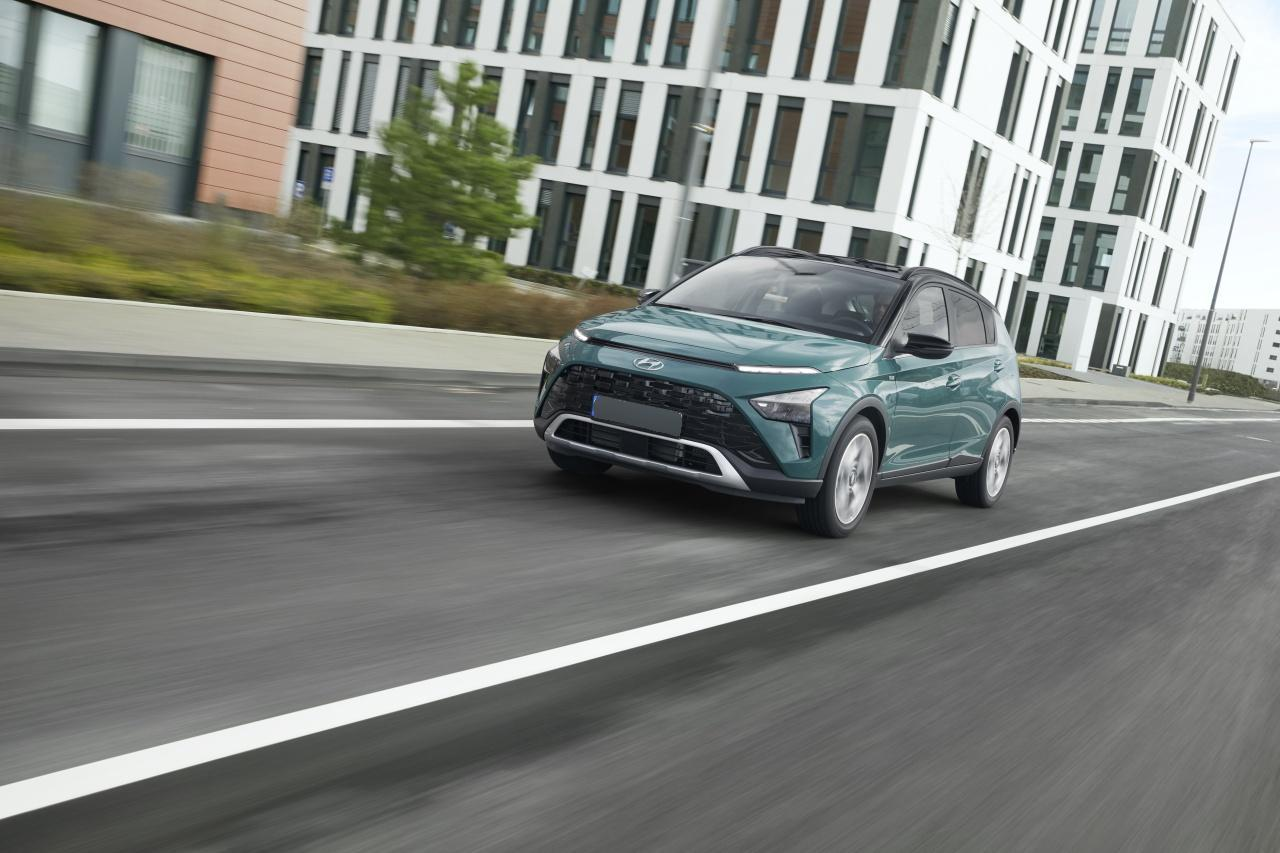


🏷️ front | Parts: ['rightfrontdoor', 'rightheadlamp', 'frontbumper', 'doorhandle', 'rightreardoorglass']


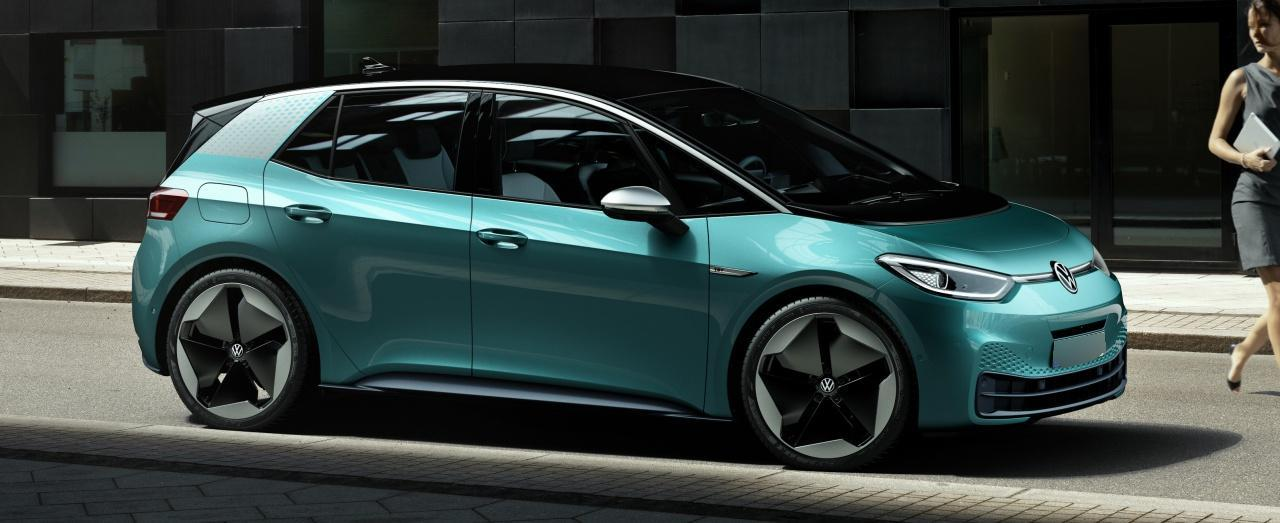


🏷️ frontleft | Parts: ['leftfrontdoor', 'leftreardoor', 'doorhandle', 'leftfender', 'leftqpanel']


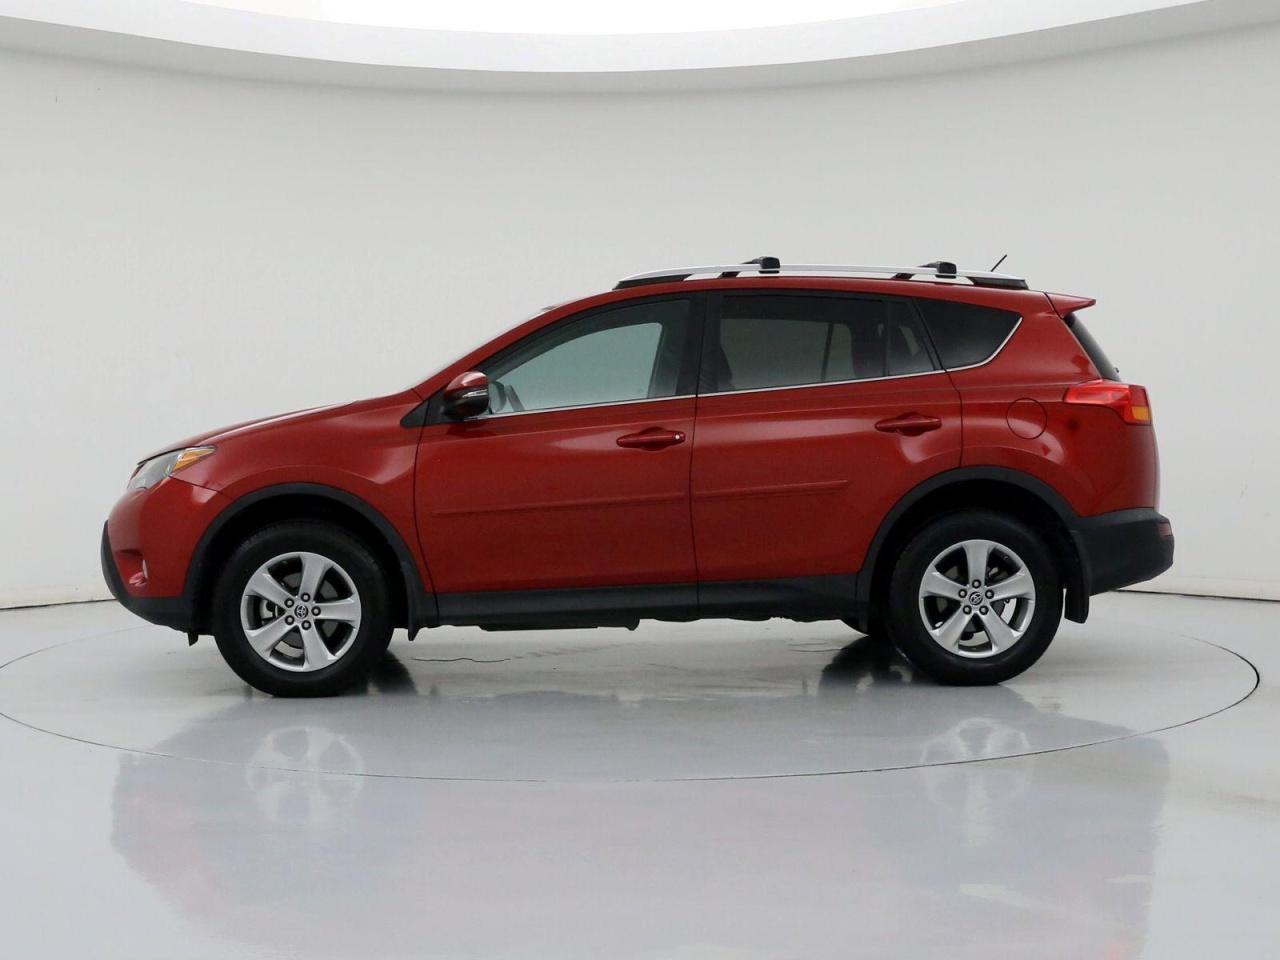


🏷️ frontleft | Parts: ['bonnet', 'frontbumper', 'frontws', 'leftfender', 'tyre']


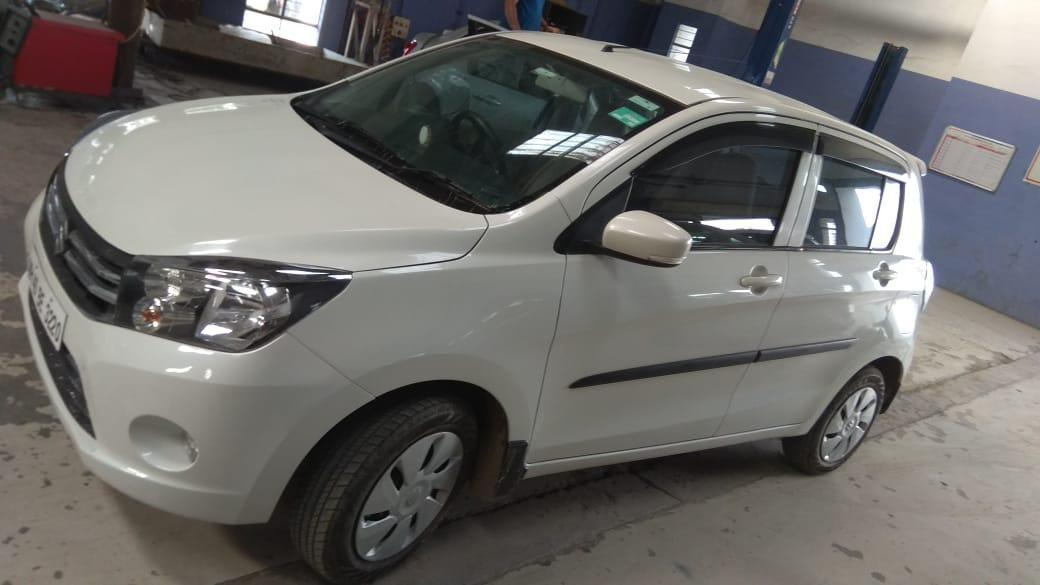


🏷️ frontright | Parts: ['doorhandle', 'rightorvm', 'rightfrontdoor', 'rightfrontdoorcladding', 'rightrunningboard']


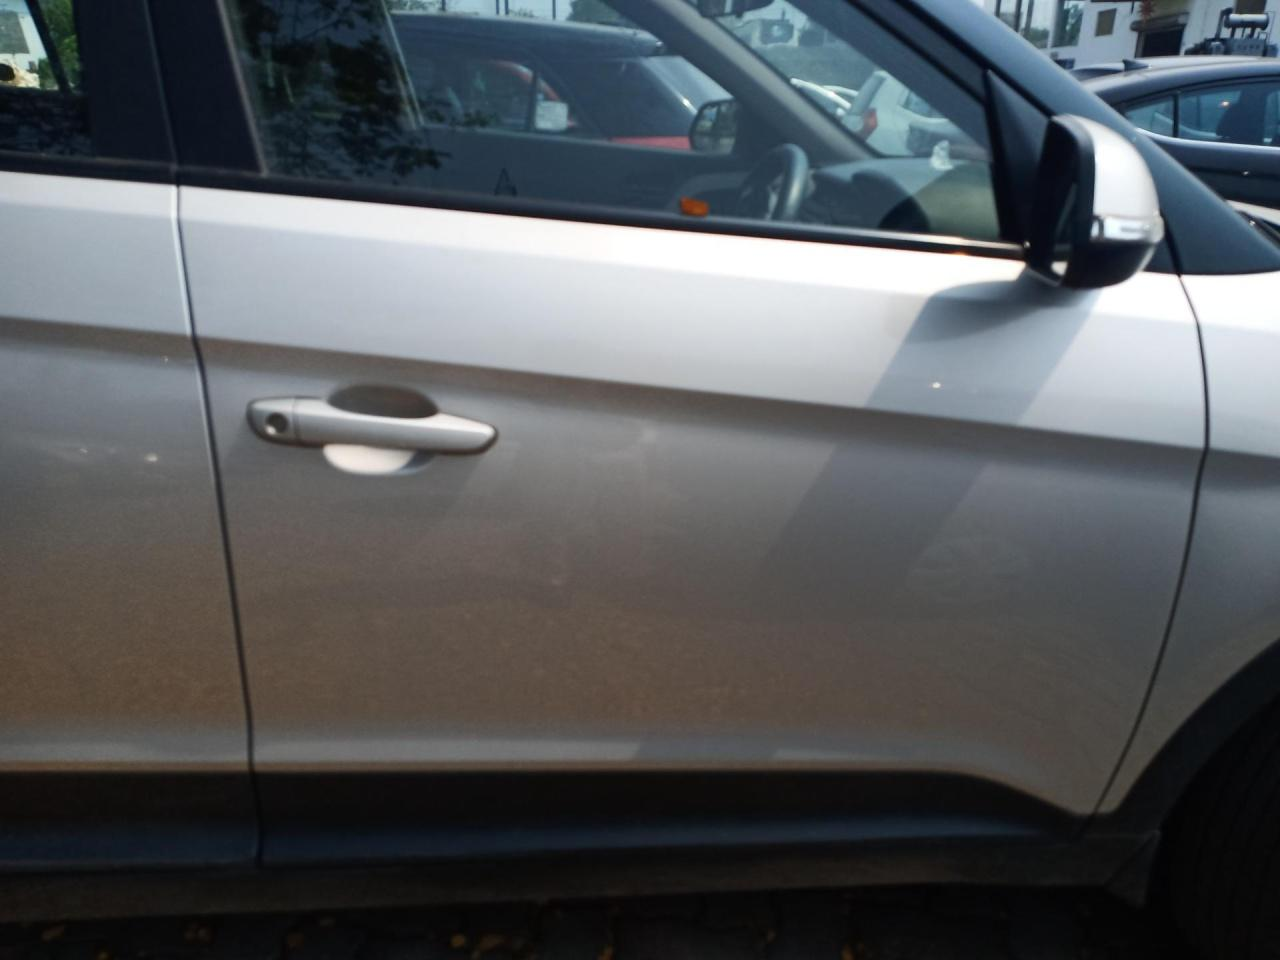


🏷️ frontright | Parts: ['righttaillamp', 'rightqpanel', 'doorhandle', 'rightwa', 'rearbumper']


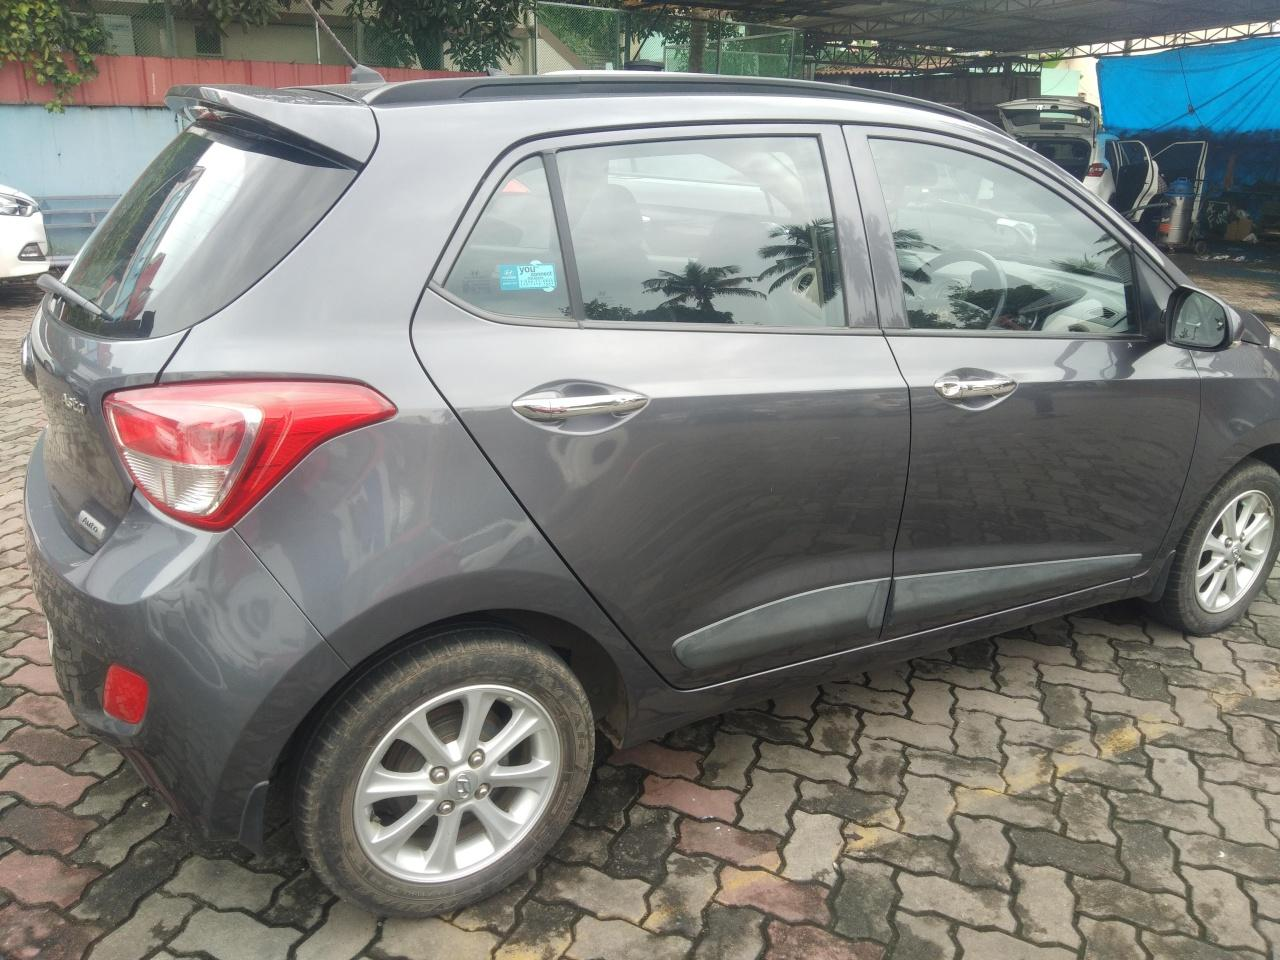


🏷️ rear | Parts: ['rearbumper', 'sensor', 'licenseplate', 'tyre', 'alloywheel']


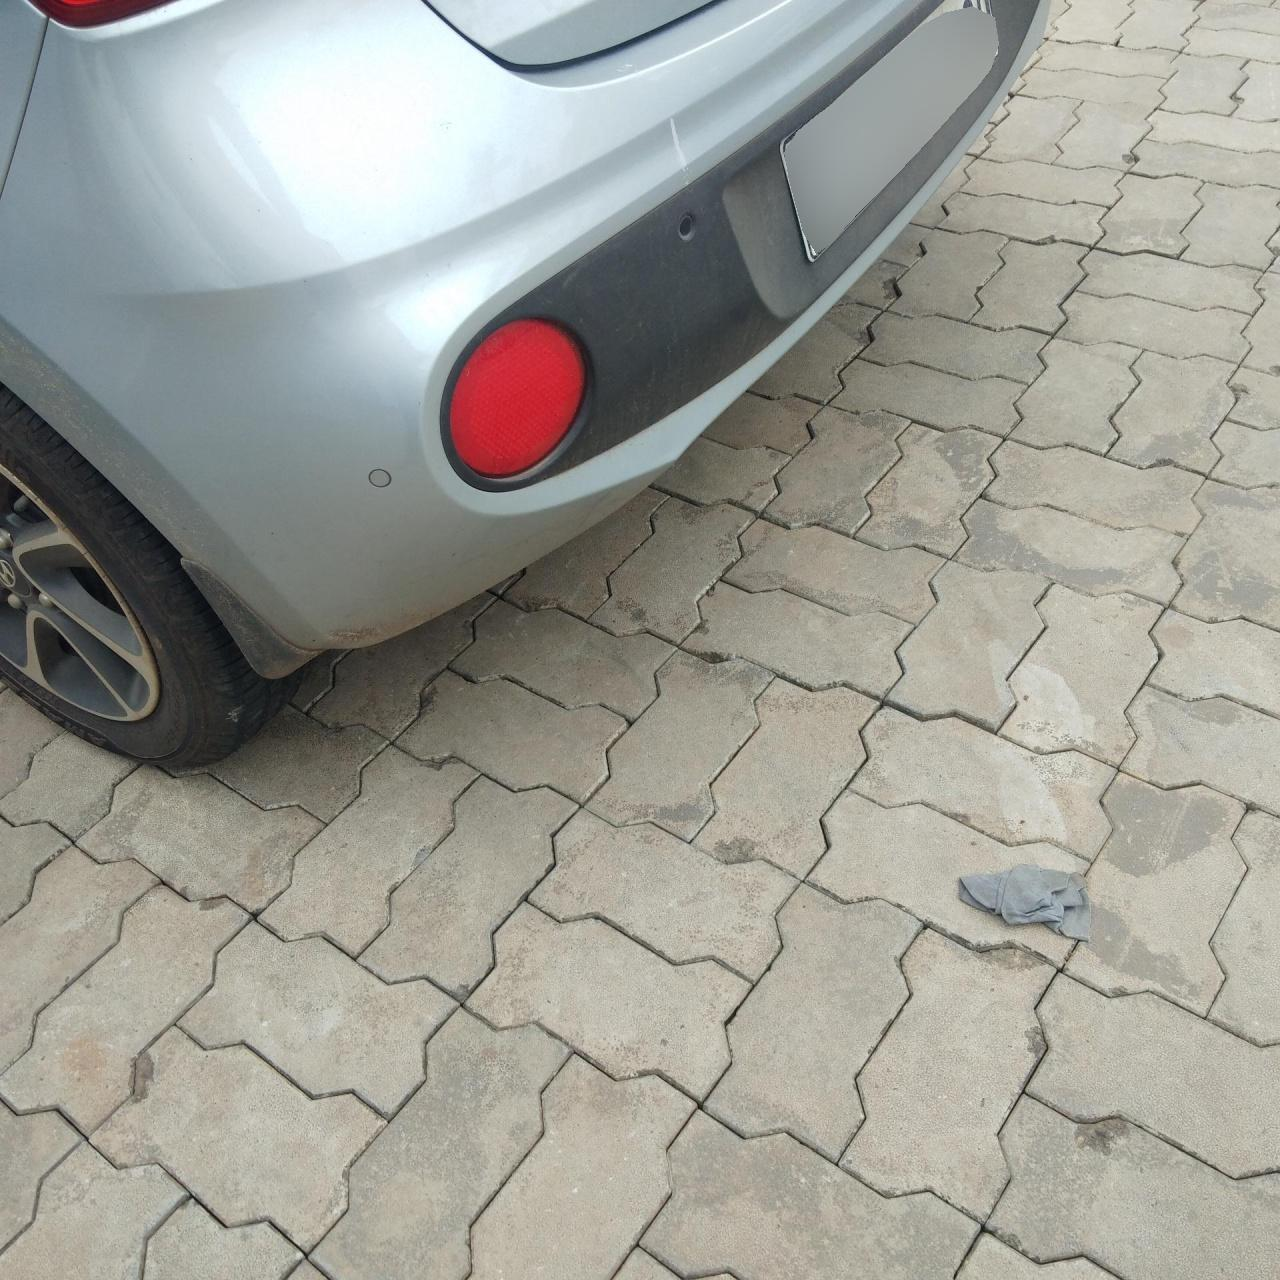


🏷️ rear | Parts: ['licenseplate', 'logo', 'Reflector', 'rearws', 'righttaillamp']


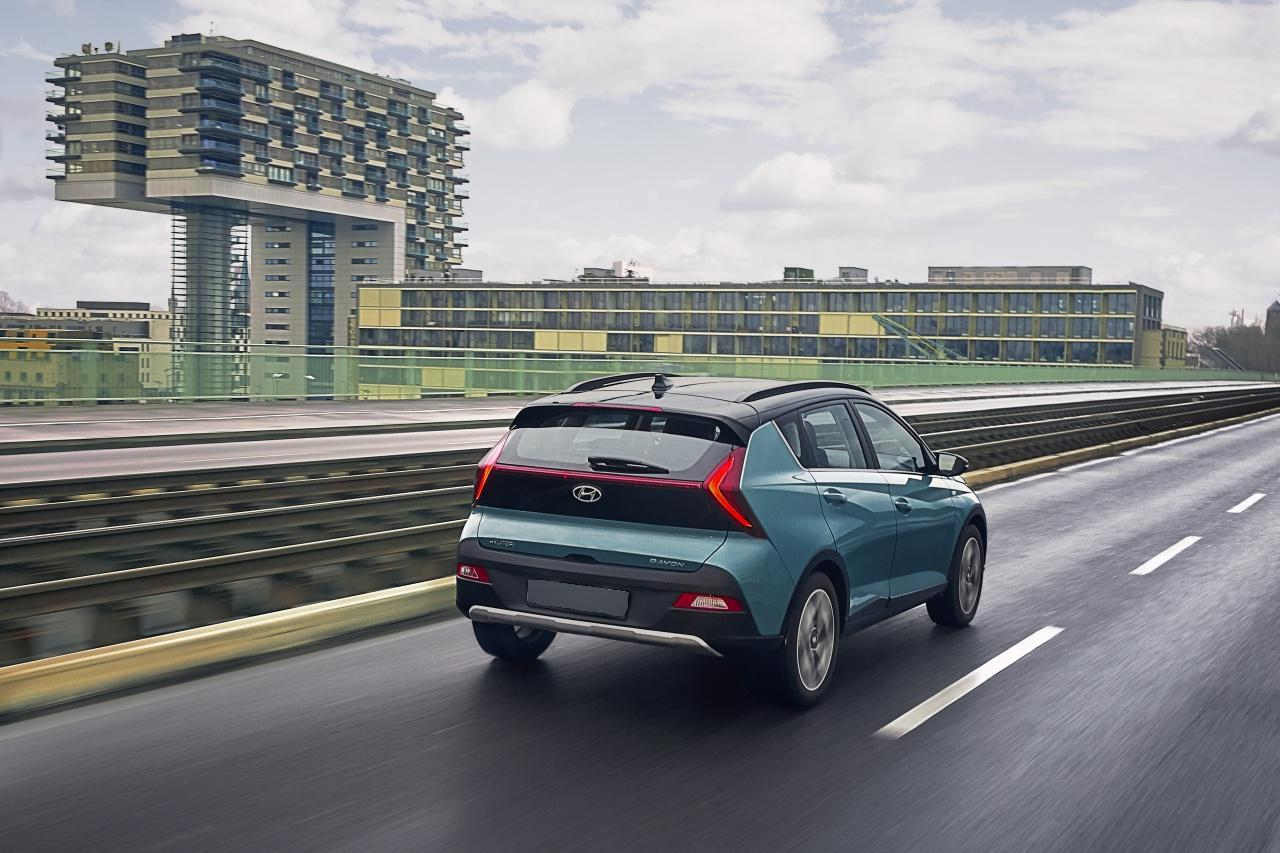


🏷️ rearleft | Parts: ['doorhandle', 'tyre', 'alloywheel', 'leftreardoor', 'leftreardoorcladding']


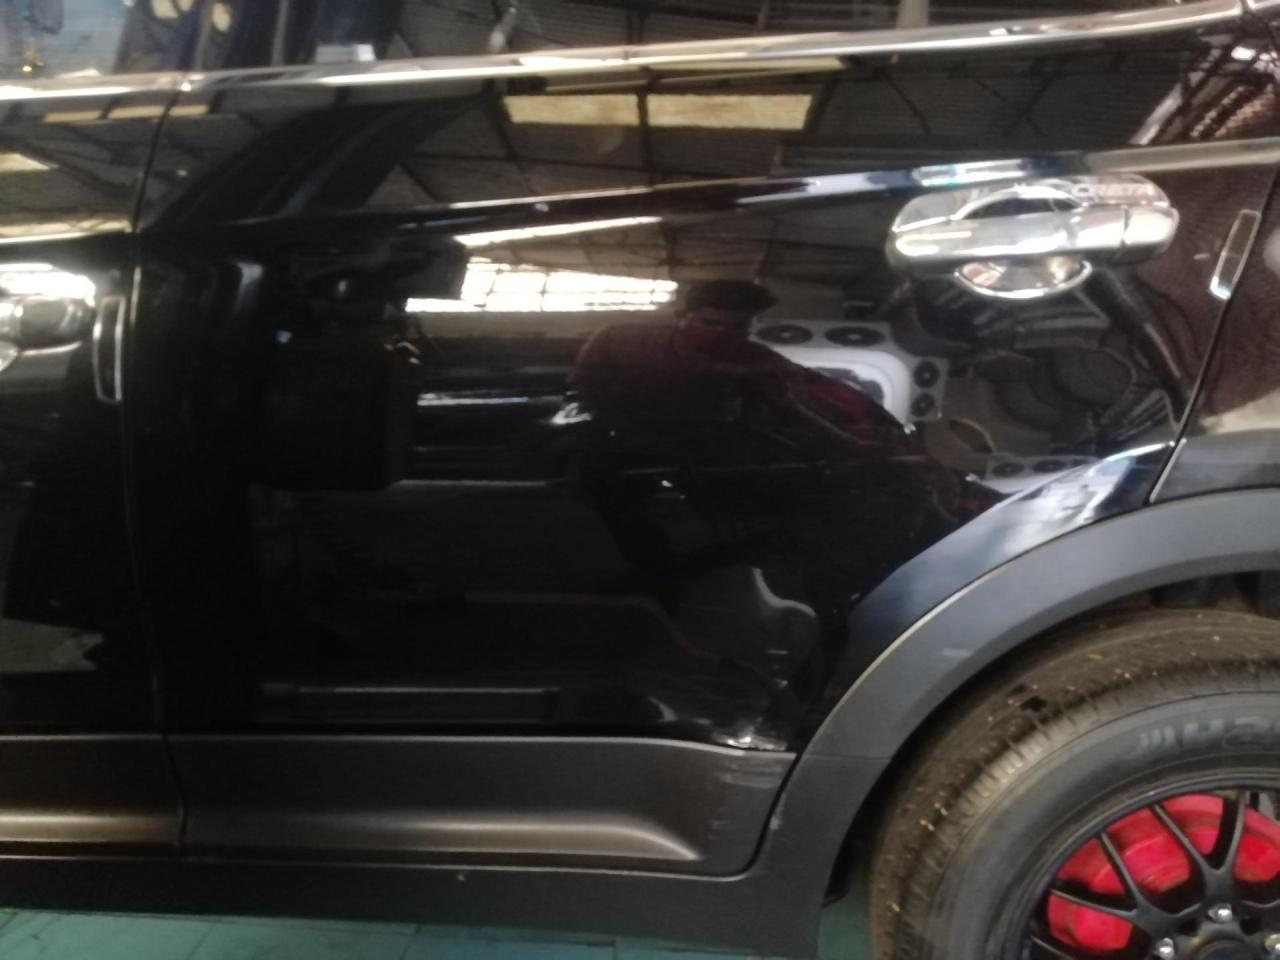


🏷️ rearleft | Parts: ['leftqpanel', 'lefttaillamp', 'doorhandle', 'fuelcap', 'tyre']


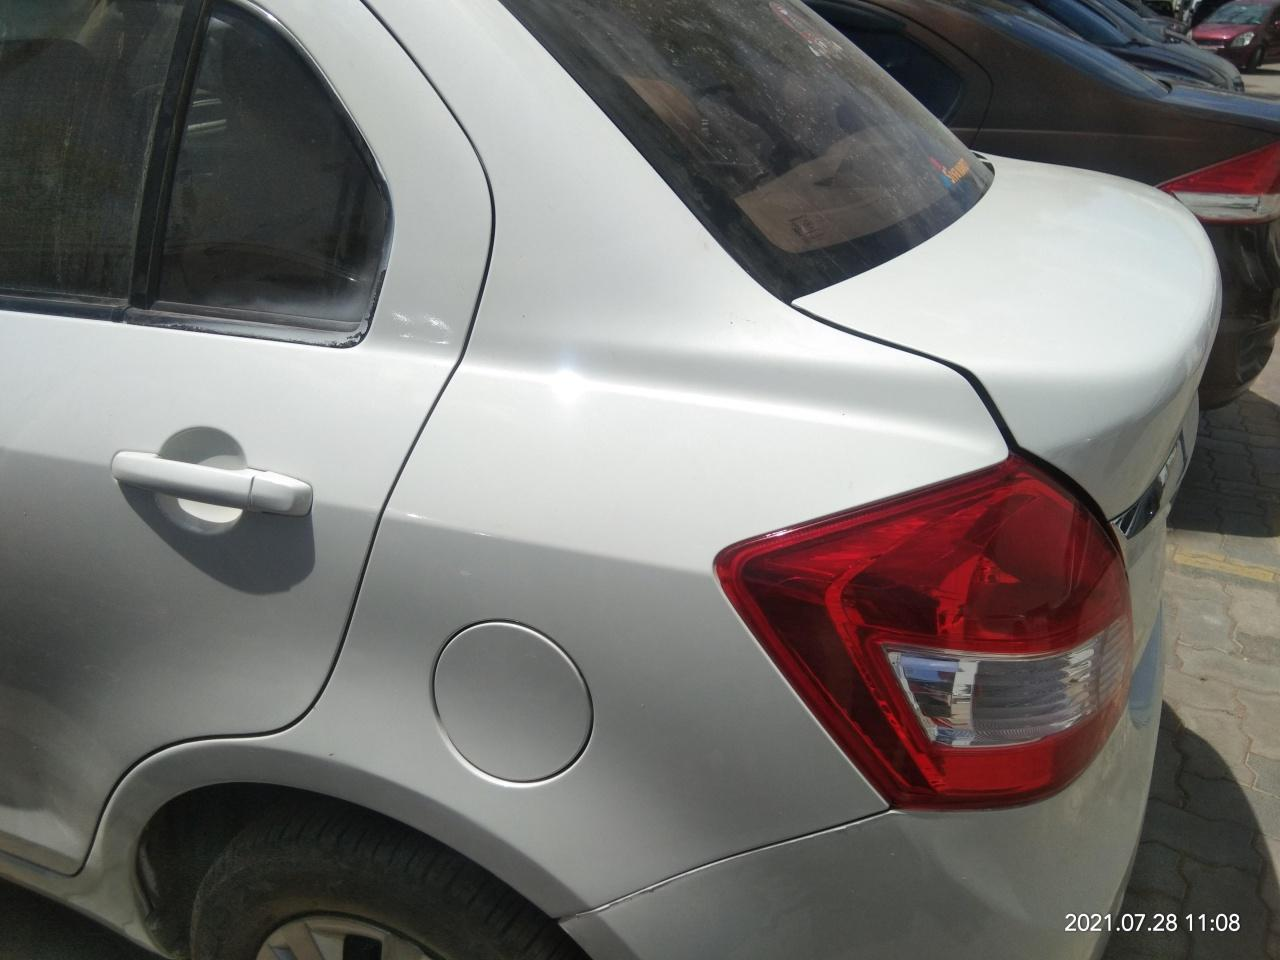


🏷️ rearright | Parts: ['rightqpanel', 'tyre', 'righttaillamp', 'rightwa', 'wheelcap']


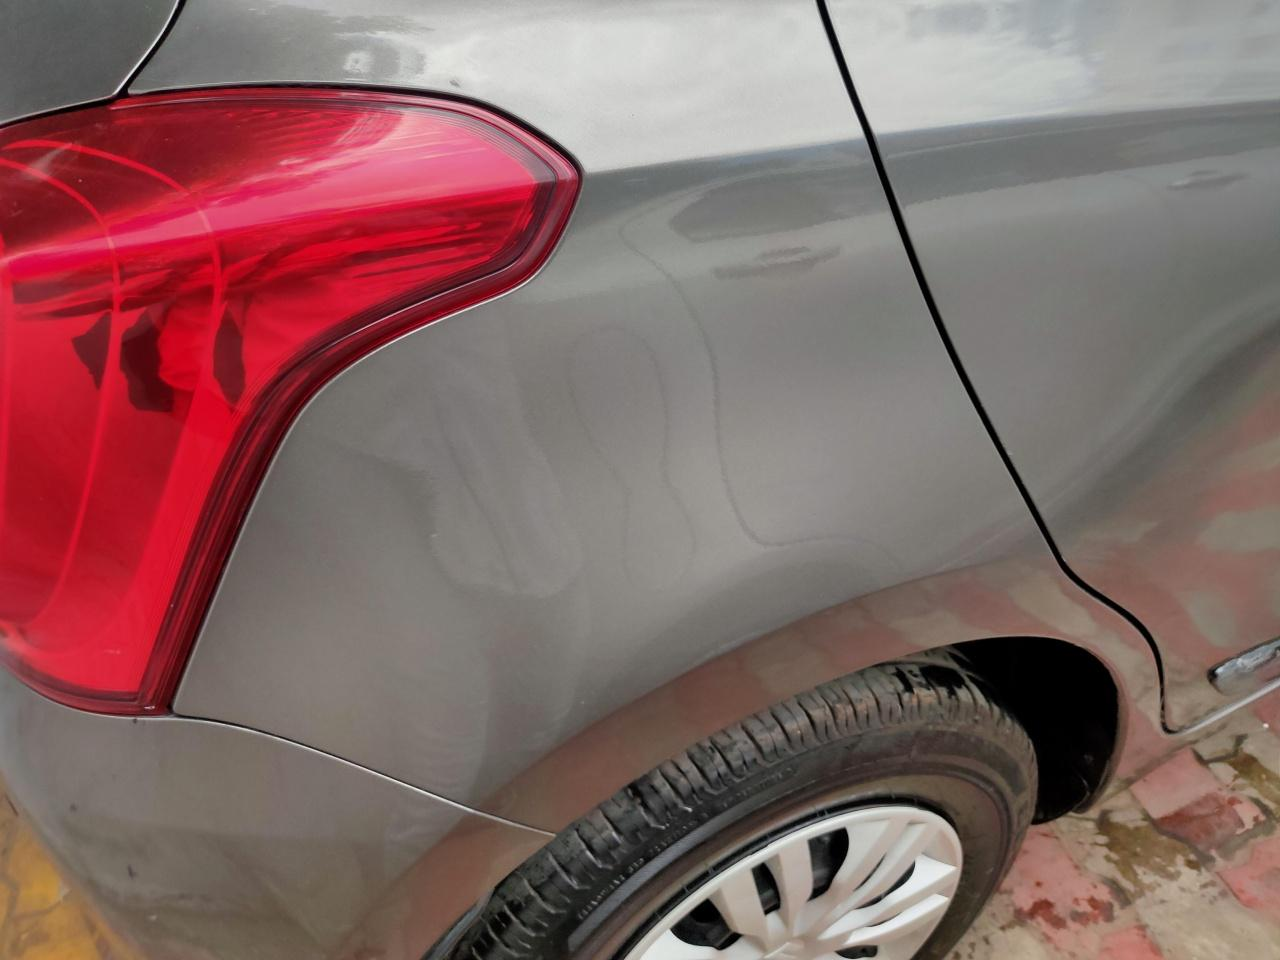


🏷️ rearright | Parts: ['namebadge', 'namebadge', 'partial_rearws', 'partial_tailgate', 'partial_rearbumper']


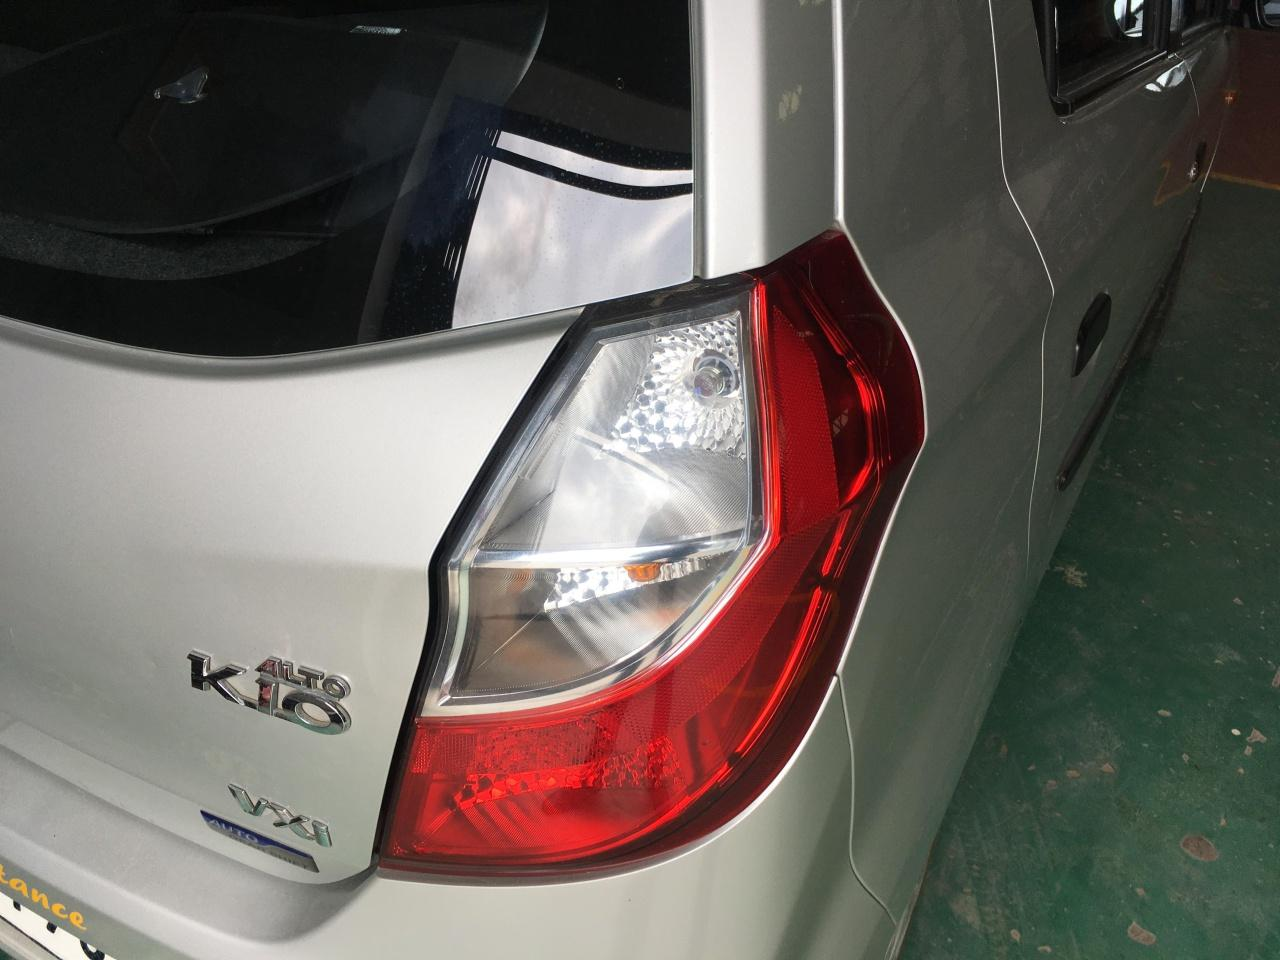

In [ ]:
import random
from IPython.display import display, Image as IPImage

# Show 2 random images per view to verify labels are correct
for view in ['front', 'frontleft', 'frontright', 'rear', 'rearleft', 'rearright']:
    images = [path for path, v in labels.items() if v == view]
    if not images:
        print(f"\n⚠️  No images for {view}")
        continue

    samples = random.sample(images, min(2, len(images)))
    for img_path in samples:
        if os.path.exists(img_path):
            print(f"\n🏷️ {view} | Parts: {all_parts_per_image[img_path][:5]}")
            display(IPImage(filename=img_path, width=400))

In [ ]:
# See what parts the "unknown" images have
unknown_images = [path for path, v in labels.items() if v == 'unknown']
print(f"Unknown images: {len(unknown_images)}\n")

# Show part distributions for unknowns
unknown_parts = Counter()
for img_path in unknown_images:
    for part in all_parts_per_image.get(img_path, []):
        unknown_parts[part.lower()] += 1

print("Most common parts in 'unknown' images:")
for part, count in unknown_parts.most_common(20):
    print(f"  {part:30s}: {count}")

Unknown images: 229

Most common parts in 'unknown' images:
  scratch                       : 195
  tyre                          : 70
  alloywheel                    : 37
  d2                            : 32
  partial_rearbumper            : 28
  roof                          : 25
  wheelcap curbrash             : 24
  leftwa                        : 20
  partial_frontws               : 17
  partial_frontbumper           : 16
  wheelcap                      : 16
  sensor                        : 15
  leftrunningboard              : 14
  partial_bonnet                : 12
  partial_tailgate              : 12
  rightwa                       : 12
  cracked                       : 12
  partial_leftfender            : 11
  partial_leftqpanel            : 11
  partial_leftfrontdoor         : 10


In [ ]:
import shutil

OUTPUT_DIR = '/content/drive/MyDrive/ClearQuote_Classified'
CLASSES = ['front', 'frontleft', 'frontright', 'rear', 'rearleft', 'rearright']

# Create class folders
for cls in CLASSES:
    os.makedirs(os.path.join(OUTPUT_DIR, cls), exist_ok=True)

# Copy images into class folders
copied = 0
skipped = 0
for img_path, view in labels.items():
    if view == 'unknown':
        skipped += 1
        continue
    if not os.path.exists(img_path):
        skipped += 1
        continue

    dest = os.path.join(OUTPUT_DIR, view, os.path.basename(img_path))
    # Handle duplicate filenames
    if os.path.exists(dest):
        name, ext = os.path.splitext(os.path.basename(img_path))
        dest = os.path.join(OUTPUT_DIR, view, f"{name}_{copied}{ext}")

    shutil.copy2(img_path, dest)
    copied += 1

print(f"✅ Copied {copied} images, skipped {skipped}")
print(f"\nFinal distribution:")
for cls in CLASSES:
    count = len(os.listdir(os.path.join(OUTPUT_DIR, cls)))
    print(f"  {cls:12s}: {count}")

# Save labels as CSV for reference
import pandas as pd
df = pd.DataFrame([
    {'image_path': path, 'filename': os.path.basename(path), 'label': view}
    for path, view in labels.items() if view != 'unknown'
])
df.to_csv(os.path.join(OUTPUT_DIR, 'labels.csv'), index=False)
print(f"\n📄 Saved labels.csv with {len(df)} entries")

✅ Copied 3671 images, skipped 246

Final distribution:
  front       : 1300
  frontleft   : 520
  frontright  : 555
  rear        : 808
  rearleft    : 189
  rearright   : 299

📄 Saved labels.csv with 3688 entries


In [ ]:
import shutil

RANDOM_DIR = os.path.join(OUTPUT_DIR, 'random')
os.makedirs(RANDOM_DIR, exist_ok=True)

copied_random = 0
for img_path in unknown_images:
    if not os.path.exists(img_path):
        continue
    dest = os.path.join(RANDOM_DIR, os.path.basename(img_path))
    if os.path.exists(dest):
        name, ext = os.path.splitext(os.path.basename(img_path))
        dest = os.path.join(RANDOM_DIR, f"{name}_{copied_random}{ext}")
    shutil.copy2(img_path, dest)
    copied_random += 1

print(f"✅ Copied {copied_random} images to 'random' class")

# Final complete distribution
print(f"\n=== FINAL DATASET ===")
ALL_CLASSES = ['front', 'frontleft', 'frontright', 'rear', 'rearleft', 'rearright', 'random']
total = 0
for cls in ALL_CLASSES:
    count = len(os.listdir(os.path.join(OUTPUT_DIR, cls)))
    total += count
    print(f"  {cls:12s}: {count}")
print(f"  {'TOTAL':12s}: {total}")

✅ Copied 228 images to 'random' class

=== FINAL DATASET ===
  front       : 1300
  frontleft   : 520
  frontright  : 555
  rear        : 808
  rearleft    : 189
  rearright   : 299
  random      : 228
  TOTAL       : 3899


In [ ]:
import tensorflow as tf
import numpy as np
import os

OUTPUT_DIR = '/content/drive/MyDrive/ClearQuote_Classified'
MODEL_SAVE_DIR = '/content/drive/MyDrive/ClearQuote_Model'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

CLASSES = ['front', 'frontleft', 'frontright', 'rear', 'rearleft', 'rearright', 'random']
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
print(f"Classes: {class_names}")
print(f"Train batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Val batches: {tf.data.experimental.cardinality(val_ds).numpy()}")

Found 3899 files belonging to 7 classes.
Using 3120 files for training.
Found 3899 files belonging to 7 classes.
Using 779 files for validation.
Classes: ['front', 'frontleft', 'frontright', 'random', 'rear', 'rearleft', 'rearright']
Train batches: 98
Val batches: 25


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Count samples per class
class_counts = []
for cls in class_names:
    count = len(os.listdir(os.path.join(OUTPUT_DIR, cls)))
    class_counts.append(count)
    print(f"  {cls}: {count}")

total = sum(class_counts)
n_classes = len(class_names)
class_weights = {i: total / (n_classes * count) for i, count in enumerate(class_counts)}

print(f"\nClass weights:")
for i, cls in enumerate(class_names):
    print(f"  {cls}: {class_weights[i]:.2f}")

  front: 1300
  frontleft: 520
  frontright: 555
  random: 228
  rear: 808
  rearleft: 189
  rearright: 299

Class weights:
  front: 0.43
  frontleft: 1.07
  frontright: 1.00
  random: 2.44
  rear: 0.69
  rearleft: 2.95
  rearright: 1.86


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze for initial training

model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,
    tf.keras.layers.Rescaling(1./127.5, offset=-1),  # MobileNetV2 preprocessing [-1, 1]
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(len(CLASSES), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1),
]

print("=== PHASE 1: Training with frozen base ===")
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

=== PHASE 1: Training with frozen base ===
Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 46s 328ms/step - accuracy: 0.3798 - loss: 1.6767 - val_accuracy: 0.4981 - val_loss: 1.3768 - learning_rate: 0.0010
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 35s 359ms/step - accuracy: 0.5151 - loss: 1.3367 - val_accuracy: 0.5456 - val_loss: 1.2144 - learning_rate: 0.0010
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 31s 315ms/step - accuracy: 0.5529 - loss: 1.2306 - val_accuracy: 0.5417 - val_loss: 1.1773 - learning_rate: 0.0010
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 41s 314ms/step - accuracy: 0.5702 - loss: 1.1727 - val_accuracy: 0.5404 - val_loss: 1.1572 - learning_rate: 0.0010
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 31s 314ms/step - accuracy: 0.5859 - loss: 1.1368 - val_accuracy: 0.5687 - val_loss: 1.1392 - learning_rate: 0.0010
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 31s 315ms/step - accuracy: 0.5904 - loss: 1.1046 - val_accuracy: 0.5558 - val_loss: 1.0962 - learning_rate: 0.0010
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 3

In [ ]:
# Unfreeze top 30 layers of MobileNetV2
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # Lower LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Trainable layers: {len([l for l in model.layers if l.trainable])}")
print("\n=== PHASE 2: Fine-tuning ===")
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Trainable layers: 8

=== PHASE 2: Fine-tuning ===
Epoch 1/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 44s 335ms/step - accuracy: 0.5901 - loss: 1.1199 - val_accuracy: 0.5802 - val_loss: 1.1558 - learning_rate: 1.0000e-04
Epoch 2/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 30s 306ms/step - accuracy: 0.6365 - loss: 0.9401 - val_accuracy: 0.6200 - val_loss: 1.0147 - learning_rate: 1.0000e-04
Epoch 3/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.6881 - loss: 0.8350
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
98/98 ━━━━━━━━━━━━━━━━━━━━ 35s 360ms/step - accuracy: 0.6769 - loss: 0.8400 - val_accuracy: 0.6098 - val_loss: 1.0048 - learning_rate: 1.0000e-04
Epoch 4/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 31s 314ms/step - accuracy: 0.7215 - loss: 0.7458 - val_accuracy: 0.5969 - val_loss: 1.0308 - learning_rate: 5.0000e-05
Epoch 5/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 31s 318ms/step - accuracy: 0.7087 - loss: 0.7357 - val_accuracy: 0.6239 - val_loss: 0.9164 - learning_rate: 5.0000e-05
Epoch 6/15
98/

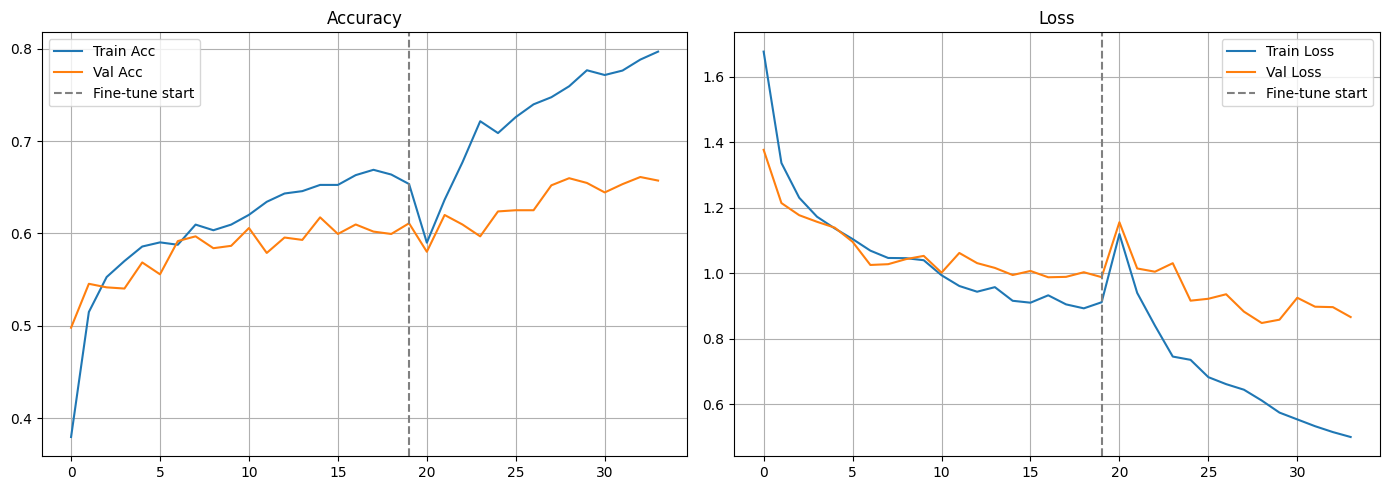

📸 Screenshot saved!


In [ ]:
import matplotlib.pyplot as plt

def plot_history(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(acc, label='Train Acc')
    ax1.plot(val_acc, label='Val Acc')
    ax1.axvline(len(h1.history['accuracy'])-1, color='gray', linestyle='--', label='Fine-tune start')
    ax1.set_title('Accuracy')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(loss, label='Train Loss')
    ax2.plot(val_loss, label='Val Loss')
    ax2.axvline(len(h1.history['loss'])-1, color='gray', linestyle='--', label='Fine-tune start')
    ax2.set_title('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_SAVE_DIR, 'training_logs.png'), dpi=150)
    plt.show()
    print("📸 Screenshot saved!")

plot_history(history1, history2)

              precision    recall  f1-score   support

       front       0.86      0.80      0.83       253
   frontleft       0.37      0.36      0.36       108
  frontright       0.35      0.41      0.38        92
      random       0.71      0.71      0.71        42
        rear       0.92      0.81      0.86       172
    rearleft       0.38      0.37      0.38        35
   rearright       0.52      0.69      0.59        77

    accuracy                           0.66       779
   macro avg       0.59      0.59      0.59       779
weighted avg       0.68      0.66      0.67       779



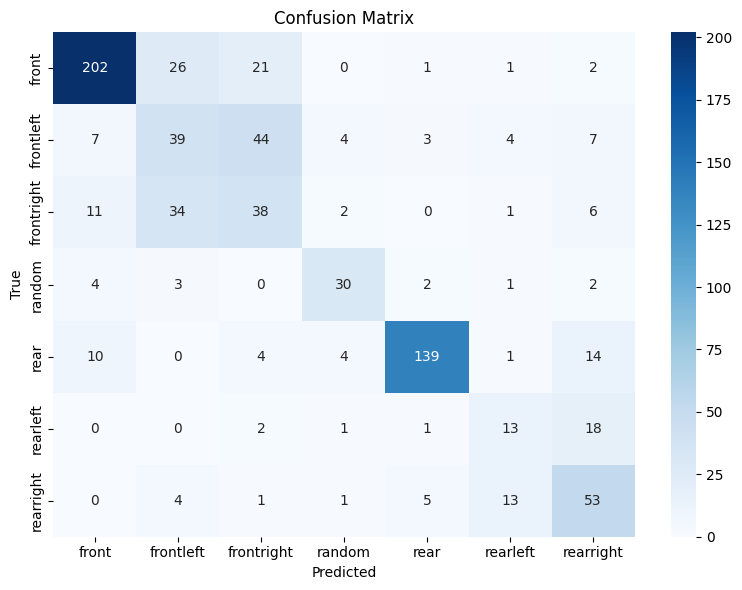

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions on validation set
y_true = []
y_pred = []

for images, labels_batch in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels_batch.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

In [ ]:
# Use EfficientNetB0 instead — better feature extraction than MobileNetV2
base_model2 = tf.keras.applications.EfficientNetB0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model2.trainable = False

# Stronger augmentation to help with side-view confusion
data_augmentation_v2 = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom((-0.15, 0.15)),
    tf.keras.layers.RandomBrightness(0.3),
    tf.keras.layers.RandomContrast(0.3),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

model2 = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation_v2,
    # EfficientNet has its own preprocessing built-in, input expects [0, 255]
    base_model2,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(CLASSES), activation='softmax')
])

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
# Boost minority classes more aggressively
boosted_weights = class_weights.copy()
for i, cls in enumerate(class_names):
    if cls in ['rearleft', 'rearright', 'frontleft', 'frontright']:
        boosted_weights[i] *= 1.5  # Extra boost for side views

print("Boosted class weights:")
for i, cls in enumerate(class_names):
    print(f"  {cls:12s}: {boosted_weights[i]:.2f}")

Boosted class weights:
  front       : 0.43
  frontleft   : 1.61
  frontright  : 1.51
  random      : 2.44
  rear        : 0.69
  rearleft    : 4.42
  rearright   : 2.79


In [ ]:
callbacks2 = [
    tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1),
]

print("=== V2 PHASE 1: Frozen base ===")
history2_p1 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=boosted_weights,
    callbacks=callbacks2
)

=== V2 PHASE 1: Frozen base ===
Epoch 1/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 47s 348ms/step - accuracy: 0.3657 - loss: 2.7129 - val_accuracy: 0.5738 - val_loss: 1.2938 - learning_rate: 0.0010
Epoch 2/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 33s 331ms/step - accuracy: 0.4599 - loss: 2.1164 - val_accuracy: 0.5263 - val_loss: 1.2541 - learning_rate: 0.0010
Epoch 3/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 34s 349ms/step - accuracy: 0.5051 - loss: 1.9112 - val_accuracy: 0.5430 - val_loss: 1.1765 - learning_rate: 0.0010
Epoch 4/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 35s 354ms/step - accuracy: 0.5279 - loss: 1.6794 - val_accuracy: 0.5584 - val_loss: 1.1799 - learning_rate: 0.0010
Epoch 5/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 36s 366ms/step - accuracy: 0.5462 - loss: 1.6612 - val_accuracy: 0.5969 - val_loss: 1.0750 - learning_rate: 0.0010
Epoch 6/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 31s 311ms/step - accuracy: 0.5516 - loss: 1.5779 - val_accuracy: 0.5353 - val_loss: 1.2550 - learning_rate: 0.0010
Epoch 7/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 30s 307ms/st

In [ ]:
base_model2.trainable = True
# Unfreeze top 50 layers for EfficientNet
for layer in base_model2.layers[:-50]:
    layer.trainable = False

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Trainable layers: {sum(1 for l in model2.trainable_variables)}")
print("\n=== V2 PHASE 2: Fine-tuning ===")
history2_p2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=boosted_weights,
    callbacks=callbacks2
)

Trainable layers: 53

=== V2 PHASE 2: Fine-tuning ===
Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 57s 386ms/step - accuracy: 0.5545 - loss: 1.5369 - val_accuracy: 0.6123 - val_loss: 1.0070 - learning_rate: 5.0000e-05
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 31s 313ms/step - accuracy: 0.5792 - loss: 1.4327 - val_accuracy: 0.6110 - val_loss: 0.9903 - learning_rate: 5.0000e-05
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 32s 326ms/step - accuracy: 0.6112 - loss: 1.2742 - val_accuracy: 0.6252 - val_loss: 0.9855 - learning_rate: 5.0000e-05
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 320ms/step - accuracy: 0.6282 - loss: 1.2209 - val_accuracy: 0.6380 - val_loss: 0.9260 - learning_rate: 5.0000e-05
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 31s 314ms/step - accuracy: 0.6333 - loss: 1.2413 - val_accuracy: 0.6393 - val_loss: 0.9482 - learning_rate: 5.0000e-05
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 31s 319ms/step - accuracy: 0.6449 - loss: 1.1576 - val_accuracy: 0.6277 - val_loss: 0.9714 - learning_rate: 5.0000e-05
Epoc

In [ ]:
y_true2 = []
y_pred2 = []

for images, labels_batch in val_ds:
    preds = model2.predict(images, verbose=0)
    y_true2.extend(np.argmax(labels_batch.numpy(), axis=1))
    y_pred2.extend(np.argmax(preds, axis=1))

print("=== V2 RESULTS ===")
print(classification_report(y_true2, y_pred2, target_names=class_names))

# Side-by-side comparison
from sklearn.metrics import f1_score
f1_v1 = f1_score(y_true, y_pred, average='macro')
f1_v2 = f1_score(y_true2, y_pred2, average='macro')
print(f"\nV1 Macro F1: {f1_v1:.3f}")
print(f"V2 Macro F1: {f1_v2:.3f}")
print(f"Improvement: {(f1_v2 - f1_v1)*100:+.1f}%")

=== V2 RESULTS ===
              precision    recall  f1-score   support

       front       0.95      0.75      0.84       253
   frontleft       0.37      0.35      0.36       108
  frontright       0.38      0.42      0.40        92
      random       0.52      0.88      0.65        42
        rear       0.89      0.76      0.82       172
    rearleft       0.37      0.63      0.47        35
   rearright       0.55      0.68      0.60        77

    accuracy                           0.65       779
   macro avg       0.58      0.64      0.59       779
weighted avg       0.70      0.65      0.67       779


V1 Macro F1: 0.588
V2 Macro F1: 0.592
Improvement: +0.5%


In [ ]:
# Higher resolution helps distinguish subtle left/right differences
IMG_SIZE_V3 = 300
BATCH_SIZE_V3 = 16  # Smaller batch for higher res

train_ds_v3 = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(IMG_SIZE_V3, IMG_SIZE_V3),
    batch_size=BATCH_SIZE_V3,
    label_mode='categorical'
)

val_ds_v3 = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(IMG_SIZE_V3, IMG_SIZE_V3),
    batch_size=BATCH_SIZE_V3,
    label_mode='categorical'
)

# Get class names before prefetching
class_names = train_ds_v3.class_names

AUTOTUNE = tf.data.AUTOTUNE
train_ds_v3 = train_ds_v3.prefetch(buffer_size=AUTOTUNE)
val_ds_v3 = val_ds_v3.prefetch(buffer_size=AUTOTUNE)

print(f"Classes: {class_names}")

Found 3899 files belonging to 7 classes.
Using 3120 files for training.
Found 3899 files belonging to 7 classes.
Using 779 files for validation.
Classes: ['front', 'frontleft', 'frontright', 'random', 'rear', 'rearleft', 'rearright']


In [ ]:
base_model3 = tf.keras.applications.EfficientNetB2(
    input_shape=(IMG_SIZE_V3, IMG_SIZE_V3, 3),
    include_top=False,
    weights='imagenet'
)
base_model3.trainable = False

data_aug_v3 = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom((-0.1, 0.1)),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

model3 = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(IMG_SIZE_V3, IMG_SIZE_V3, 3)),
    data_aug_v3,
    base_model3,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(CLASSES), activation='softmax')
])

model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("=== V3 PHASE 1: Frozen base ===")
history3_p1 = model3.fit(
    train_ds_v3,
    validation_data=val_ds_v3,
    epochs=25,
    class_weight=boosted_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1),
    ]
)

31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== V3 PHASE 1: Frozen base ===
Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


195/195 ━━━━━━━━━━━━━━━━━━━━ 56s 210ms/step - accuracy: 0.4208 - loss: 2.5180 - val_accuracy: 0.5456 - val_loss: 1.2417 - learning_rate: 0.0010
Epoch 2/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 36s 183ms/step - accuracy: 0.4888 - loss: 1.9745 - val_accuracy: 0.5430 - val_loss: 1.2263 - learning_rate: 0.0010
Epoch 3/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 37s 192ms/step - accuracy: 0.5359 - loss: 1.7399 - val_accuracy: 0.5944 - val_loss: 1.0876 - learning_rate: 0.0010
Epoch 4/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 35s 177ms/step - accuracy: 0.5577 - loss: 1.6408 - val_accuracy: 0.5802 - val_loss: 1.0958 - learning_rate: 0.0010
Epoch 5/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 36s 184ms/step - accuracy: 0.5679 - loss: 1.5595 - val_accuracy: 0.5828 - val_loss: 1.0737 - learning_rate: 0.0010
Epoch 6/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 40s 179ms/step - accuracy: 0.5728 - loss: 1.5173 - val_accuracy: 0.5597 - val_loss: 1.0969 - learning_rate: 0.0010
Epoch 7/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 36s 187ms/step - accuracy: 0.5862 - loss:

In [ ]:
base_model3.trainable = True
for layer in base_model3.layers[:-60]:
    layer.trainable = False

model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n=== V3 PHASE 2: Fine-tuning ===")
history3_p2 = model3.fit(
    train_ds_v3,
    validation_data=val_ds_v3,
    epochs=25,
    class_weight=boosted_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1),
    ]
)


=== V3 PHASE 2: Fine-tuning ===
Epoch 1/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 70s 235ms/step - accuracy: 0.5372 - loss: 1.6342 - val_accuracy: 0.6200 - val_loss: 0.9351 - learning_rate: 3.0000e-05
Epoch 2/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 41s 211ms/step - accuracy: 0.5804 - loss: 1.4447 - val_accuracy: 0.6393 - val_loss: 0.8886 - learning_rate: 3.0000e-05
Epoch 3/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 41s 208ms/step - accuracy: 0.5987 - loss: 1.3695 - val_accuracy: 0.6496 - val_loss: 0.8491 - learning_rate: 3.0000e-05
Epoch 4/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 44s 224ms/step - accuracy: 0.6125 - loss: 1.2636 - val_accuracy: 0.6598 - val_loss: 0.8448 - learning_rate: 3.0000e-05
Epoch 5/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 78s 205ms/step - accuracy: 0.6365 - loss: 1.1686 - val_accuracy: 0.6611 - val_loss: 0.8413 - learning_rate: 3.0000e-05
Epoch 6/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 41s 203ms/step - accuracy: 0.6494 - loss: 1.1535 - val_accuracy: 0.6637 - val_loss: 0.8229 - learning_rate: 3.0000e-05
Epoch 7/25
19

In [ ]:
y_true3 = []
y_pred3 = []

for images, labels_batch in val_ds_v3:
    preds = model3.predict(images, verbose=0)
    y_true3.extend(np.argmax(labels_batch.numpy(), axis=1))
    y_pred3.extend(np.argmax(preds, axis=1))

print("=== V3 RESULTS ===")
print(classification_report(y_true3, y_pred3, target_names=class_names))

from sklearn.metrics import f1_score
f1_v3 = f1_score(y_true3, y_pred3, average='macro')
print(f"\nV1 Macro F1: {f1_v1:.3f}")
print(f"V2 Macro F1: {f1_v2:.3f}")
print(f"V3 Macro F1: {f1_v3:.3f}")

=== V3 RESULTS ===
              precision    recall  f1-score   support

       front       0.91      0.82      0.86       253
   frontleft       0.39      0.29      0.33       108
  frontright       0.38      0.53      0.45        92
      random       0.63      0.86      0.73        42
        rear       0.92      0.79      0.85       172
    rearleft       0.38      0.54      0.45        35
   rearright       0.55      0.64      0.59        77

    accuracy                           0.68       779
   macro avg       0.59      0.64      0.61       779
weighted avg       0.70      0.68      0.68       779


V1 Macro F1: 0.588
V2 Macro F1: 0.592
V3 Macro F1: 0.607


In [ ]:
# Save everything to Drive so nothing is lost
model3.save('/content/drive/MyDrive/ClearQuote_Model/model_v3.keras')
model2.save('/content/drive/MyDrive/ClearQuote_Model/model_v2.keras')
model.save('/content/drive/MyDrive/ClearQuote_Model/model_v1.keras')

# Save training histories
import pickle
histories = {
    'v1': (history1.history, history2.history),
    'v2': (history2_p1.history, history2_p2.history),
    'v3': (history3_p1.history, history3_p2.history),
    'scores': {'v1': f1_v1, 'v2': f1_v2, 'v3': f1_v3}
}
with open('/content/drive/MyDrive/ClearQuote_Model/histories.pkl', 'wb') as f:
    pickle.dump(histories, f)

print("✅ All saved to Drive. Safe to close Colab.")

✅ All saved to Drive. Safe to close Colab.
